# Gradient Descent Algorithm

## Example 1

Suppose we want to find the minimum of the function $$ f(x,y) = (x-47)^2 + (y - 0.1)^2 + 2. $$

In [1]:
#------------------------
# Import packages
#------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import norm


# Change the plotting style
plt.style.use('seaborn-whitegrid')

# Uncomment to make pictures interactive
# %matplotlib notebook
%matplotlib inline

In [2]:
#------------------------
# Create functions
#------------------------

# Create the cost function
def costFunction(x,y):
    f = (x-47)**2 + (y - 0.1)**2 + 2
    return f

# Create the gradient vector
def gradf(x,y):
    gradient = np.array([2*(x - 47), 2*(y - 0.1)**1])
    return gradient

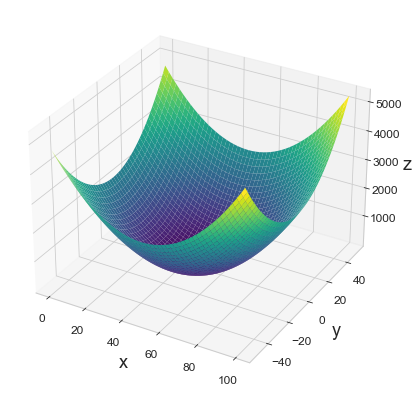

In [3]:
#------------------------
# Find values of function f
#------------------------

# Create points to plot
x = np.linspace(0, 100, 50)
y = np.linspace(-50, 50, 50)

# Makes grid for plotting from point above
X, Y = np.meshgrid(x, y)

# Cost function output for points on grid
Z = costFunction(X, Y)

#------------------------
# Create plot of function f
#------------------------

# Make figure size
fig = plt.figure(figsize=(12,7))

# Make 3d axis for plot
ax = plt.axes(projection='3d')

# Add surface to plot
ax.plot_surface(X, Y, Z, rstride = 1, cstride = 1, cmap='viridis', edgecolor='none')

# Create title and label axes
#ax.set_title(r'$f(x,y)$', fontsize = 20);
ax.set_xlabel('x', fontsize = 18)
ax.set_ylabel('y', fontsize = 18)
ax.set_zlabel('z', fontsize = 18)

# Set general font size
plt.rcParams['font.size'] = '12'

# Set tick font size
for label in (ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels()):
    label.set_fontsize(12)
    
plt.savefig('costFunction.pdf', bbox_inches='tight')

# Show plot
plt.show()

In [4]:
#------------------------
# Create variables
#------------------------

# Starting point
x0 = 80
y0 = 20

# Step size to move along gradient
gamma = 0.01
# Make vector for calculations later
gammaVec = gamma*np.ones(2)

# Starting point X0=(x0,y0) where X=(x,y)
X0 = np.array([x0,y0])

# initialize num of steps to take
totalNumSteps = 0
# create a max number of steps to take
maxSteps = 1000
# how close we want to be to f
tolerance = 0.0001
# initial diff
norms = 100

# initialize x value to starting point
currentX = X0

#initialize value of objective function to f(X0)
currentCostFunValues = costFunction(X0[0], X0[1])

#------------------------
# Initialize lists
#------------------------

# creates list of all (x,y) pairs
xyValuesList = [currentX]
# creates list of all cost function values
costFunValuesList = [currentCostFunValues]
# creates list of norms
normsList = [norms]

#------------------------
# Gradient descent calcs
#------------------------

while((totalNumSteps < maxSteps)&(norms > tolerance)):
    
    # Calculate new (x,y) values
    newX = currentX - gammaVec*gradf(currentX[0], currentX[1])
    # Calculate new function values with new (x,y) values
    newCostFunValues = costFunction(newX[0],newX[1])
    
    # Calculate the difference between current and new function values
    norms = norm(newX-currentX,2)
    normsList.append(norms)
    
    # Add 1 to counter for total number of steps
    totalNumSteps += 1
    
    # Add to list of (x,y) values
    xyValuesList.append(newX)
    # Add to list of cost function values
    costFunValuesList.append(newCostFunValues)
    
    # Reassign current (x,y) to new (x,y)
    currentX = newX
    # Reassign current cost function values to new cost function values
    currentCostFunValues = newCostFunValues

In [5]:
#------------------------
# Format data for plot
#------------------------

# Data from above
df = pd.DataFrame(xyValuesList, columns = ['x', 'y'])

# Function values of f (to compare)
epsilon = 2
x = np.linspace(min(df['x'])-epsilon, max(df['x']+epsilon), 30)
y = np.linspace(min(df['y'])-epsilon, max(df['y']+epsilon), 30)

# Makes grid for plotting
X, Y = np.meshgrid(x, y)
# Cost function output for points on grid
Z = costFunction(X, Y)

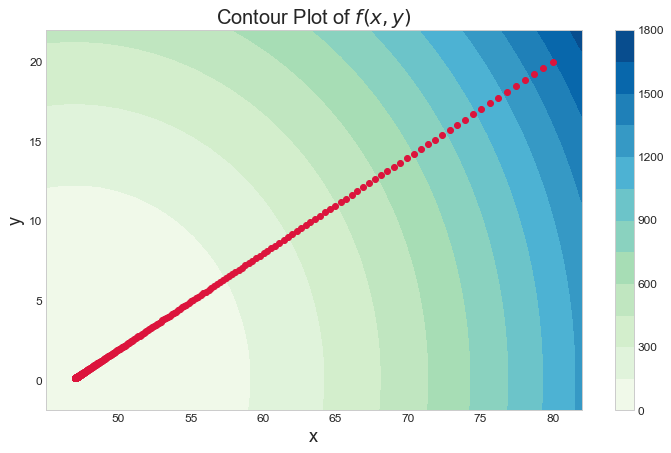

In [6]:
# ------------------------
# Create contour plot
#------------------------

# Make figure size
plt.figure(figsize=(12,7))

# Create contour plot
plt.contourf(X, Y, Z, 15, cmap='GnBu')

# Plot our xyValues
plt.plot(df['x'], df['y'], 'o', color = 'crimson')

# Set general font size
plt.rcParams['font.size'] = '12'

# Label axes and make title
plt.xlabel('x', fontsize = 18)
plt.ylabel('y', fontsize = 18)
plt.title('Contour Plot of $f(x,y)$', fontsize = 20)

# Create colorbar for height
plt.colorbar()

plt.savefig('contourPlot.pdf', bbox_inches='tight')

# Show plot
plt.show()

In [7]:
df

,x,y
0,80.000000,20.000000
1,79.340000,19.602000
2,78.693200,19.211960
3,78.059336,18.829721
4,77.438149,18.455126
...,...,...
441,47.004459,0.102689
442,47.004370,0.102635
443,47.004282,0.102582
444,47.004197,0.102531


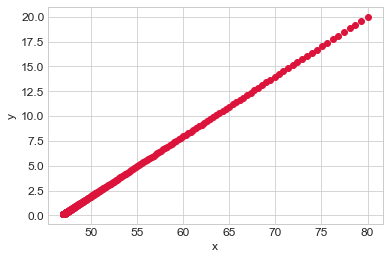

In [8]:
# Create the plot
plt.plot(df['x'], df['y'], 'o', color = 'crimson')
plt.xlabel('x')
plt.ylabel('y')
 
# Show the plot
plt.show()

In [9]:
normsList

[100,
 0.7707165497120165,
 0.7553022187177778,
 0.7401961743434263,
 0.7253922508565532,
 0.7108844058394199,
 0.6966667177226357,
 0.6827333833681829,
 0.6690787157008167,
 0.6556971413868057,
 0.6425831985590669,
 0.6297315345878841,
 0.6171369038961341,
 0.604794165818205,
 0.5926982825018469,
 0.5808443168518095,
 0.5692274305147725,
 0.5578428819044755,
 0.5466860242663875,
 0.5357523037810594,
 0.5250372577054299,
 0.5145365125513227,
 0.5042457823003008,
 0.4941608666542872,
 0.48427764932120254,
 0.4745920963347892,
 0.46510025440808944,
 0.4557982493199239,
 0.4466822843335326,
 0.43774863864685865,
 0.4289936658739165,
 0.4204137925564424,
 0.4120055167053115,
 0.4037654063712072,
 0.39569009824378387,
 0.3877762962789045,
 0.3800207703533259,
 0.3724203549462629,
 0.3649719478473361,
 0.3576725088903873,
 0.3505190587125803,
 0.343508677538331,
 0.33663850398756623,
 0.32990573390781486,
 0.32330761922965723,
 0.3168414668450652,
 0.31050463750815915,
 0.30429454475800066,
